# GMM Classification on SNGP Embeddings

Load saved SNGP train/test embeddings, fit one Gaussian per CIFAR-10 class using the training labels as the latent variable `z`, and evaluate GMM posterior classification on test embeddings.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / "src").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

print("repo root:", REPO_ROOT)

repo root: /w/20252/wjcai/uq/manygp


In [2]:
EMBEDDING_PATH = REPO_ROOT / "notebooks" / "gmm" / "sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz"

if not EMBEDDING_PATH.exists():
    candidates = sorted((REPO_ROOT / "notebooks" / "gmm").glob("sngp_embeddings_*.npz"))
    if not candidates:
        raise FileNotFoundError("No sngp_embeddings_*.npz files found in notebooks/gmm")
    EMBEDDING_PATH = candidates[-1]

data = np.load(EMBEDDING_PATH, allow_pickle=True)

train_embeddings = data["train_embeddings"].astype(np.float64)
train_labels = data["train_labels"].astype(np.int64)
test_embeddings = data["test_embeddings"].astype(np.float64)
test_labels = data["test_labels"].astype(np.int64)
classes = data["classes"]
checkpoint_id = str(data["checkpoint_id"]) if "checkpoint_id" in data else EMBEDDING_PATH.stem.removeprefix("sngp_embeddings_")

print("embedding file:", EMBEDDING_PATH)
print("checkpoint id:", checkpoint_id)
print("train embeddings:", train_embeddings.shape)
print("test embeddings:", test_embeddings.shape)
print("classes:", classes.tolist())

embedding file: /w/20252/wjcai/uq/manygp/notebooks/gmm/sngp_embeddings_cifar10_sngp_epoch175_acc0.9323.npz
checkpoint id: cifar10_sngp_epoch175_acc0.9323
train embeddings: (50000, 128)
test embeddings: (10000, 128)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Fit the GMM with labels fixed: `z = y`. The class prior `p(z)` is the empirical class frequency in the training set, and `p(x | z)` is a full-covariance Gaussian estimated from the embeddings for that class.

In [3]:
def fit_label_assigned_gmm(x, y, num_classes, covariance_reg=1e-3):
    dim = x.shape[1]
    means = np.zeros((num_classes, dim), dtype=np.float64)
    covariances = np.zeros((num_classes, dim, dim), dtype=np.float64)
    priors = np.zeros(num_classes, dtype=np.float64)

    global_variance = np.var(x, axis=0).mean()
    reg = covariance_reg * max(global_variance, 1e-12)

    for cls in range(num_classes):
        class_x = x[y == cls]
        if len(class_x) == 0:
            raise ValueError(f"class {cls} has no training samples")

        priors[cls] = len(class_x) / len(x)
        means[cls] = class_x.mean(axis=0)
        centered = class_x - means[cls]
        cov = centered.T @ centered / max(len(class_x) - 1, 1)
        covariances[cls] = cov + reg * np.eye(dim)

    return priors, means, covariances, reg


num_classes = len(classes)
class_priors, class_means, class_covariances, covariance_reg = fit_label_assigned_gmm(
    train_embeddings,
    train_labels,
    num_classes=num_classes,
    covariance_reg=1e-3,
)

print("class priors:", np.round(class_priors, 4))
print("covariance diagonal regularizer:", covariance_reg)

class priors: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
covariance diagonal regularizer: 0.0005269016154350051


In [4]:
def logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out


def gaussian_logpdf_by_class(x, means, covariances):
    num_classes, dim = means.shape
    logpdf = np.empty((x.shape[0], num_classes), dtype=np.float64)
    log_2pi = dim * np.log(2.0 * np.pi)

    for cls in range(num_classes):
        chol = np.linalg.cholesky(covariances[cls])
        diff = (x - means[cls]).T
        solved = np.linalg.solve(chol, diff)
        mahalanobis = np.sum(solved * solved, axis=0)
        logdet = 2.0 * np.sum(np.log(np.diag(chol)))
        logpdf[:, cls] = -0.5 * (log_2pi + logdet + mahalanobis)

    return logpdf


def gmm_probabilities(x, priors, means, covariances, train_log_px_max=None):
    log_likelihood = gaussian_logpdf_by_class(x, means, covariances)
    log_joint = np.log(priors)[None, :] + log_likelihood
    log_px = logsumexp(log_joint, axis=1)
    posterior = np.exp(log_joint - log_px[:, None])

    if train_log_px_max is None:
        train_log_px_max = np.max(log_px)

    marginal_weight = np.exp(log_px - train_log_px_max)
    marginal_weight = np.clip(marginal_weight, 0.0, 1.0)

    uniform = np.full_like(posterior, 1.0 / posterior.shape[1])
    blended = posterior * marginal_weight[:, None] + uniform * (1.0 - marginal_weight[:, None])
    blended = blended / blended.sum(axis=1, keepdims=True)

    return {
        "log_likelihood": log_likelihood,
        "log_joint": log_joint,
        "log_px": log_px,
        "marginal_weight": marginal_weight,
        "posterior": posterior,
        "blended": blended,
    }


train_gmm = gmm_probabilities(train_embeddings, class_priors, class_means, class_covariances)
test_gmm = gmm_probabilities(
    test_embeddings,
    class_priors,
    class_means,
    class_covariances,
    train_log_px_max=np.max(train_gmm["log_px"]),
)

print("train log p(x) range:", (train_gmm["log_px"].min(), train_gmm["log_px"].max()))
print("test log p(x) range:", (test_gmm["log_px"].min(), test_gmm["log_px"].max()))
print("test p(x) blend weight range:", (test_gmm["marginal_weight"].min(), test_gmm["marginal_weight"].max()))

train log p(x) range: (np.float64(231.00527496973694), np.float64(307.86038237382536))
test log p(x) range: (np.float64(210.7396818097656), np.float64(306.9839442349923))
test p(x) blend weight range: (np.float64(6.622403924911472e-43), np.float64(0.416262945099439))


For classification, first compute the GMM posterior `p_gmm(y | x) = p(x, z=y) / p(x)`. Then blend it with a uniform class distribution using the marginal-density confidence: `p_final(y | x) = p_gmm(y | x) * p_x_weight + uniform(y) * (1 - p_x_weight)`. Raw continuous `p(x)` is a density, so `p_x_weight` is `exp(log p(x) - max_train_log p(x))` clipped into `[0, 1]`.

In [5]:
def negative_log_likelihood(probs, labels, eps=1e-12):
    true_class_probs = probs[np.arange(len(labels)), labels]
    return -np.mean(np.log(np.clip(true_class_probs, eps, 1.0)))


train_posterior_pred = train_gmm["posterior"].argmax(axis=1)
test_posterior_pred = test_gmm["posterior"].argmax(axis=1)
test_blended_pred = test_gmm["blended"].argmax(axis=1)

train_posterior_acc = np.mean(train_posterior_pred == train_labels)
test_posterior_acc = np.mean(test_posterior_pred == test_labels)
test_blended_acc = np.mean(test_blended_pred == test_labels)

test_posterior_nll = negative_log_likelihood(test_gmm["posterior"], test_labels)
test_blended_nll = negative_log_likelihood(test_gmm["blended"], test_labels)

print(f"train GMM posterior accuracy: {train_posterior_acc * 100:.2f}%")
print(f"test GMM posterior accuracy: {test_posterior_acc * 100:.2f}%")
print(f"test blended probability accuracy: {test_blended_acc * 100:.2f}%")
print(f"test GMM posterior NLL: {test_posterior_nll:.4f}")
print(f"test blended probability NLL: {test_blended_nll:.4f}")


train GMM posterior accuracy: 98.79%
test GMM posterior accuracy: 92.65%
test blended probability accuracy: 91.75%
test GMM posterior NLL: 1.2391
test blended probability NLL: 2.2953


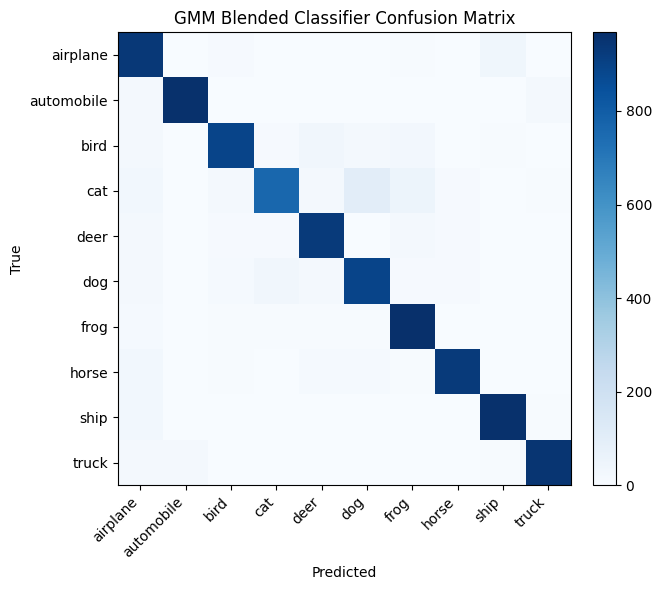

In [6]:
confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(test_labels, test_blended_pred):
    confusion[true_label, pred_label] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion, cmap="Blues")
ax.set_title("GMM Blended Classifier Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(num_classes), labels=classes, rotation=45, ha="right")
ax.set_yticks(np.arange(num_classes), labels=classes)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [7]:
result_path = REPO_ROOT / "notebooks" / "gmm" / f"gmm_results_{checkpoint_id}.npz"
np.savez_compressed(
    result_path,
    class_priors=class_priors,
    class_means=class_means,
    class_covariances=class_covariances,
    covariance_reg=covariance_reg,
    train_log_px=train_gmm["log_px"],
    test_log_px=test_gmm["log_px"],
    test_marginal_weight=test_gmm["marginal_weight"],
    test_posterior_probs=test_gmm["posterior"],
    test_blended_probs=test_gmm["blended"],
    test_blended_pred=test_blended_pred,
    test_labels=test_labels,
    confusion=confusion,
    classes=classes,
    checkpoint_id=checkpoint_id,
    embedding_path=str(EMBEDDING_PATH),
    train_posterior_accuracy=train_posterior_acc,
    test_posterior_accuracy=test_posterior_acc,
    test_blended_accuracy=test_blended_acc,
    test_posterior_nll=test_posterior_nll,
    test_blended_nll=test_blended_nll,
)
print("saved:", result_path)


saved: /w/20252/wjcai/uq/manygp/notebooks/gmm/gmm_results_cifar10_sngp_epoch175_acc0.9323.npz
